# 02 — Isolation Forest

**Hour 2, 70–105 min: Feature selection, preprocessing, and building the model**

In the last notebook we explored the data by eye. Now we teach a machine to do the same
thing — spot unusual transactions — without ever telling it what "fraud" looks like.

We'll follow these steps, matching the slides exactly:
1. Import libraries
2. Load data
3. Inspect data
4. Select features
5. Preprocess (scale)
6. Train Isolation Forest
7. Generate predictions
8. Identify anomalies
9. Visualize anomalies
10. Interpret results

All scikit-learn syntax below was verified against the current official documentation.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 5.5)

## 2. Load data

In [2]:
df = pd.read_csv("../data/bank_transaction_anomaly_dataset.csv")
df.shape

(5004, 8)

## 3. Inspect data

Quick sanity check before we do anything else: any missing values?

In [3]:
df.isna().sum()

transaction_id                     0
customer_id                        0
transaction_amount                 0
transaction_frequency              0
transaction_hour                   0
distance_from_usual_location_km    0
account_age_days                   0
is_actual_anomaly                  0
dtype: int64

No missing values — good, we can skip imputation for this dataset.

## 4. Select features

**What are we doing?** Choosing which columns actually describe a transaction's BEHAVIOUR —
the things that could make it look unusual.

**Why?** `transaction_id` and `customer_id` are just labels/identifiers — they carry no
meaningful "distance" information for the model (two customer IDs being numerically close
means nothing). We exclude them, along with the ground-truth `is_actual_anomaly` column,
which a real unsupervised system would never have.

In [4]:
feature_cols = [
    "transaction_amount",
    "transaction_frequency",
    "transaction_hour",
    "distance_from_usual_location_km",
    "account_age_days",
]

X = df[feature_cols].copy()
X.head()

,transaction_amount,transaction_frequency,transaction_hour,distance_from_usual_location_km,account_age_days
0,480000,1,8,0.4,1224
1,23354,1,11,1.2,759
2,63667,1,17,3.4,949
3,35539,1,11,2.1,2364
4,12527,1,19,0.1,3356


## 5. Preprocess: scale the features

**Why does this matter?** `transaction_amount` ranges into the millions, while
`transaction_hour` only ranges from 0 to 23. Isolation Forest's random splits work directly on
these raw values — a feature with a huge numeric range can end up dominating how the trees
split, purely because of its scale, not because it's actually more informative.

`StandardScaler` puts every feature on a comparable scale (mean 0, standard deviation 1).

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Turn it back into a labelled DataFrame just for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.describe().round(2)

,transaction_amount,transaction_frequency,transaction_hour,distance_from_usual_location_km,account_age_days
count,5004.00,5004.00,5004.00,5004.00,5004.00
mean,-0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-0.22,-0.26,-3.25,-0.23,-1.68
25%,-0.19,-0.26,-0.64,-0.19,-0.90
50%,-0.17,-0.26,0.07,-0.14,-0.02
75%,-0.11,0.14,0.78,-0.05,0.83
max,14.02,12.48,2.44,14.46,1.82


Every column now has mean ≈ 0 and standard deviation ≈ 1 — exactly what we wanted.

## 6. Train Isolation Forest

**What are we doing?** Fitting the model on our scaled features.

**Parameters:**
- `n_estimators=100` — build 100 random trees (the ensemble from the slides).
- `contamination=0.03` — our estimate that roughly 3% of transactions are unusual (a
  reasonable starting guess for this dataset — we'll experiment with this value in
  Notebook 03).
- `random_state=42` — makes the results reproducible run to run.

In [6]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.03,
    random_state=42,
)

model.fit(X_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


## 7. Generate predictions

**What are we doing?** Asking the fitted model for a normal/anomaly flag on every transaction.

**What should we expect?** An array of `1`s (normal) and `-1`s (anomaly), one per row —
verified against the current scikit-learn documentation.

In [7]:
predictions = model.predict(X_scaled)
predictions[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [8]:
df["predicted_label"] = predictions
df["is_anomaly"] = (predictions == -1).astype(int)

df["is_anomaly"].value_counts()

is_anomaly
0    4853
1     151
Name: count, dtype: int64

## 8. Identify anomalies

Let's also compute the continuous anomaly score for every transaction, using
`score_samples()`. **Lower scores = more unusual** (this was confirmed against the current
scikit-learn docs).

In [9]:
df["anomaly_score"] = model.score_samples(X_scaled)

flagged = df[df["is_anomaly"] == 1].sort_values("anomaly_score")
print(f"Isolation Forest flagged {len(flagged)} transactions out of {len(df)}.")
flagged[["transaction_id", "customer_id", "transaction_amount", "transaction_frequency",
         "transaction_hour", "distance_from_usual_location_km", "anomaly_score"]].head(10)

Isolation Forest flagged 151 transactions out of 5004.


,transaction_id,customer_id,transaction_amount,transaction_frequency,transaction_hour,distance_from_usual_location_km,anomaly_score
2361,TXN502361,CUST20846,667451,1,2,382.5,-0.737202
3960,TXN503960,CUST20439,439164,3,1,306.7,-0.736738
1449,TXN501449,CUST20531,471188,3,1,359.4,-0.734296
3181,TXN503181,CUST20087,875490,3,3,270.6,-0.733356
3475,TXN503475,CUST20517,672373,3,2,253.8,-0.732963
4747,TXN504747,CUST20256,12260,30,0,18.2,-0.732658
663,TXN500663,CUST20256,4690,30,0,16.7,-0.728948
3347,TXN503347,CUST20256,51102,30,0,22.5,-0.728868
3304,TXN503304,CUST20256,45052,30,0,24.4,-0.728868
4022,TXN504022,CUST20015,840081,3,3,320.7,-0.728499


**Business perspective:** These are the transactions the model considers LEAST like the
rest of the data — the ones an investigator should look at first. Notice the mix: some have
huge amounts, some have unusual frequency, some are a combination — exactly matching the
point/contextual/collective anomaly types from the slides.

## 9. Visualize anomalies

### 9a. Anomaly score distribution

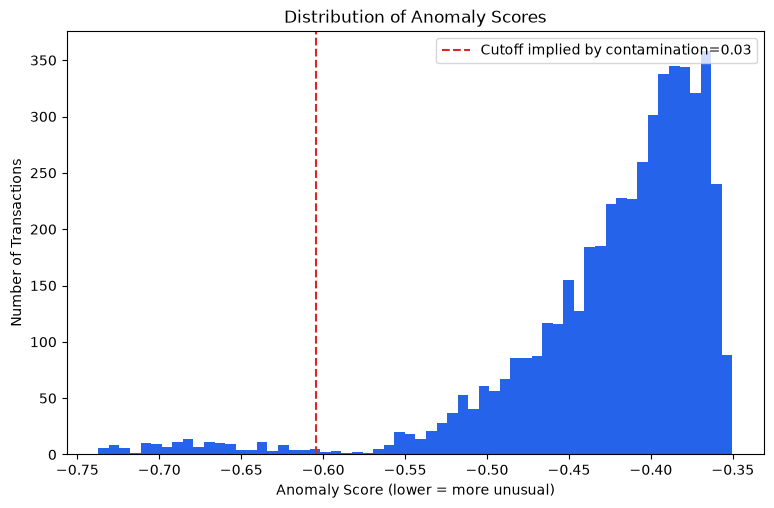

In [10]:
fig, ax = plt.subplots()
ax.hist(df["anomaly_score"], bins=60, color="#2563EB")
ax.axvline(df.loc[df["is_anomaly"] == 1, "anomaly_score"].max(), color="#DC2626",
           linestyle="--", label="Cutoff implied by contamination=0.03")
ax.set_xlabel("Anomaly Score (lower = more unusual)")
ax.set_ylabel("Number of Transactions")
ax.set_title("Distribution of Anomaly Scores")
ax.legend()
plt.show()

### 9b. Flagged transactions on a scatter plot

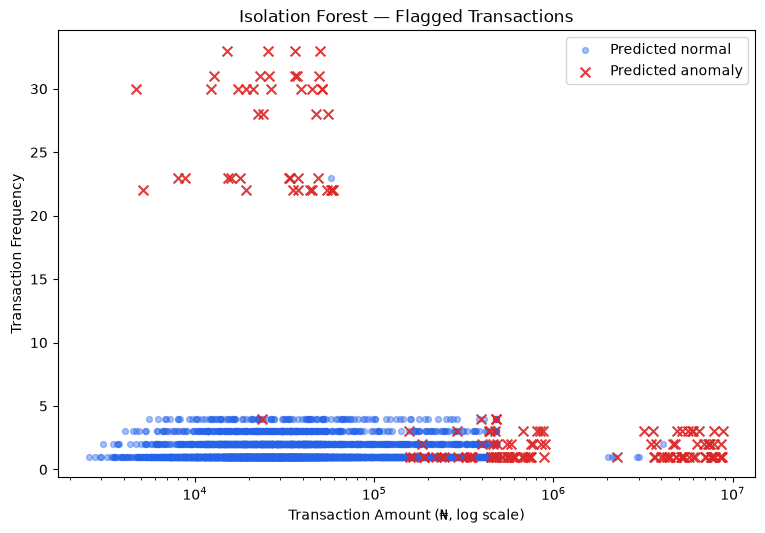

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.8))
normal = df[df["is_anomaly"] == 0]
anomaly = df[df["is_anomaly"] == 1]

ax.scatter(normal["transaction_amount"], normal["transaction_frequency"],
           s=18, alpha=0.4, color="#2563EB", label="Predicted normal")
ax.scatter(anomaly["transaction_amount"], anomaly["transaction_frequency"],
           s=50, alpha=0.9, color="#DC2626", marker="x", label="Predicted anomaly")
ax.set_xscale("log")
ax.set_xlabel("Transaction Amount (₦, log scale)")
ax.set_ylabel("Transaction Frequency")
ax.set_title("Isolation Forest — Flagged Transactions")
ax.legend()
plt.show()

## 10. Interpret results

Let's compare our predictions against the ground-truth `is_actual_anomaly` column — remember,
we only have this because our dataset is synthetic and built for teaching. A real fraud system
usually doesn't get this feedback until much later, if at all.

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion matrix (rows = actual, columns = predicted):")
print(confusion_matrix(df["is_actual_anomaly"], df["is_anomaly"]))
print()
print(classification_report(df["is_actual_anomaly"], df["is_anomaly"], digits=2,
                             target_names=["Normal", "Anomaly"]))

Confusion matrix (rows = actual, columns = predicted):
[[4846    4]
 [   7  147]]

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      4850
     Anomaly       0.97      0.95      0.96       154

    accuracy                           1.00      5004
   macro avg       0.99      0.98      0.98      5004
weighted avg       1.00      1.00      1.00      5004



**What does this mean in business terms?**
- **Precision** tells us: of everything we flagged, what fraction were REALLY unusual?
- **Recall** tells us: of everything that was REALLY unusual, what fraction did we catch?
- A model can be tuned to catch almost everything (high recall) at the cost of far more false
  alarms (lower precision), or vice versa — that trade-off is controlled largely by
  `contamination`, which is exactly what we experiment with next, in Notebook 03.

### Recap
- We selected meaningful features and excluded IDs and the ground-truth label.
- We scaled the features so no single column dominates the distance calculations.
- We trained an Isolation Forest and used `predict()` and `score_samples()` to flag and rank
  unusual transactions.
- We visualized the result and connected it back to precision/recall.

**Next: `03_Anomaly_Detection_Mini_Project.ipynb`** — the contamination mini-challenge, and
building the complete anomaly detection pipeline end to end.